In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

XTrain, XTest, yTrain, yTest = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Dense, Flatten
from sklearn.base import BaseEstimator, ClassifierMixin

timeSteps = XTrainScaled.shape[1]

class LSTMWrapper(BaseEstimator, ClassifierMixin):

    def build_model(self):
        model = Sequential([
            ConvLSTM2D(32, kernel_size=(1, 3), activation="relu", input_shape=(1, 1, timeSteps, 1), padding='same'),
            Flatten(),
            Dense(16, activation="relu"),
            Dense(3, activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        return model

    def fit(self, X, y):
        Xr = X.reshape(X.shape[0], 1, 1, timeSteps, 1)

        self.model = self.build_model()
        self.model.fit(Xr, y, epochs=5, batch_size=64, verbose=0)
        self.classes_ = np.unique(y)

        return self

    def predict_proba(self, X):
        Xr = X.reshape(X.shape[0], 1, 1, timeSteps, 1)
        return self.model.predict(Xr, verbose=0)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaModel = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stackModel = StackingClassifier(
    estimators=[
        ("lstm", LSTMWrapper()),
        ("ada", adaModel)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5
)


In [ ]:
from sklearn.metrics import accuracy_score
stackModel.fit(XTrainScaled, yTrain)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


StackingClassifier(cv=5,
                   estimators=[('lstm', LSTMWrapper()),
                               ('ada',
                                AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                                                   learning_rate=0.5,
                                                   n_estimators=200,
                                                   random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   stack_method='predict_proba')

In [ ]:
yPred = stackModel.predict(XTestScaled)

print("Accuracy:")
print(accuracy_score(yTest, yPred))

Accuracy:
0.8457702617470829


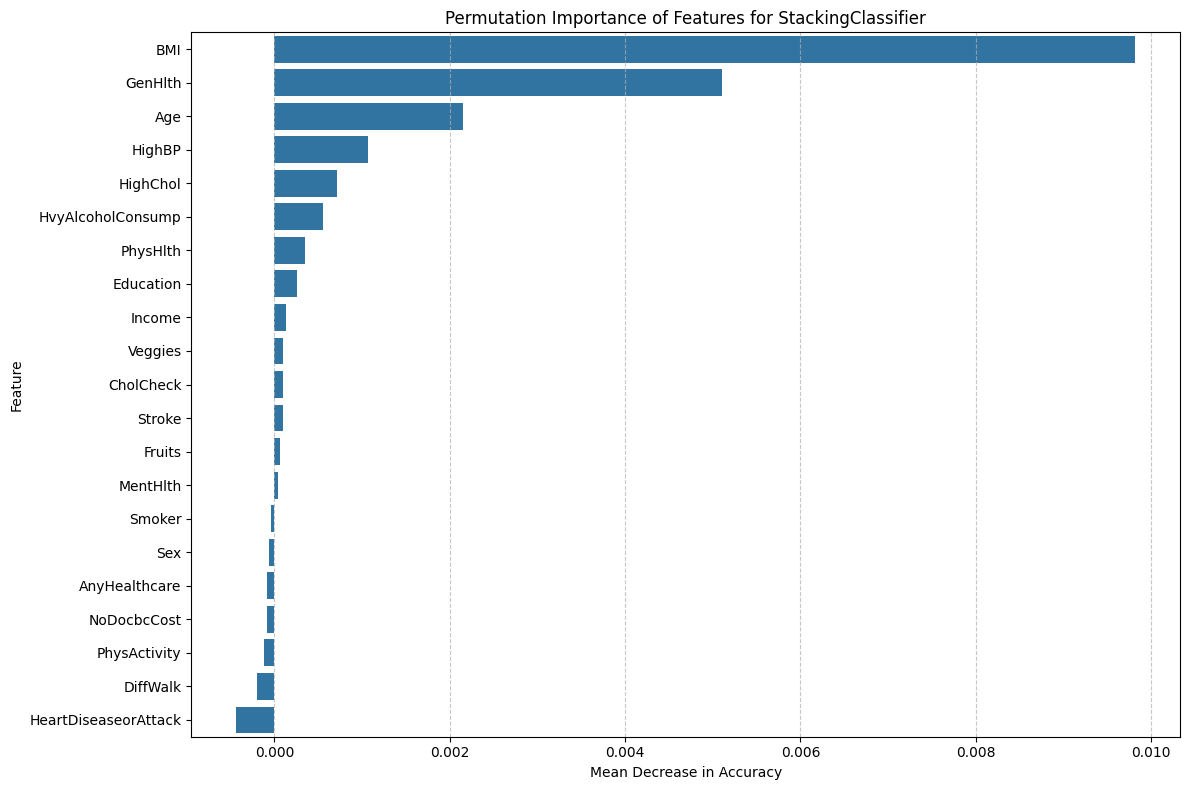

In [30]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = X.columns.tolist()
perm_importance = permutation_importance(
    stackModel,
    XTestScaled,
    yTest,
    n_repeats=1,
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
})

perm_df = perm_df.sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance_mean', y='feature', data=perm_df)
plt.title('Permutation Importance of Features for StackingClassifier')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
!pip install shap
import shap

In [ ]:
num_samples_for_shap = 100
np.random.seed(42)
sample_indices = np.random.choice(XTestScaled.shape[0], num_samples_for_shap, replace=False)
XTestScaled_sample = XTestScaled[sample_indices]
X_sample_original = XTest.iloc[sample_indices]

XTrainScaled_background = shap.utils.sample(XTrainScaled, 100)
explainer = shap.KernelExplainer(stackModel.predict_proba, XTrainScaled_background)

shap_values = explainer.shap_values(XTestScaled_sample)
class_to_visualize = 0
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[class_to_visualize],
    XTestScaled_sample,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Summary Plot for Class {class_to_visualize}')
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:

!pip install lime

import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=XTrainScaled,
    feature_names=feature_names,
    class_names=['No Diabetes', 'Prediabetes', 'Diabetes'],
    mode='classification'
)

X_to_explain = XTestScaled[instance_idx]
X_original_for_display = XTest.iloc[instance_idx]

explanation = explainer.explain_instance(
    data_row=X_to_explain,
    predict_fn=stackModel.predict_proba,
    num_features=10
    )
print("\nLIME Explanation:")
explanation.show_in_notebook(show_table=True, show_all=False)

In [ ]:
import tensorflow as tf
convlstm_model = stackModel.estimators_[0][1].model
instance_idx = 0
X_saliency = XTestScaled[instance_idx]
X_saliency_reshaped = X_saliency.reshape(1, 1, 1, timeSteps, 1)
input_tensor = tf.convert_to_tensor(X_saliency_reshaped, dtype=tf.float32)
predicted_class = np.argmax(stackModel.predict(X_saliency.reshape(1, -1)))

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    predictions = convlstm_model(input_tensor)
    score = predictions[0, predicted_class]

gradients = tape.gradient(score, input_tensor)
saliency_values = gradients.numpy().squeeze()
saliency_df = pd.DataFrame({
    'feature': feature_names,
    'saliency': saliency_values
})

saliency_df['abs_saliency'] = saliency_df['saliency'].abs()
saliency_df = saliency_df.sort_values(by='abs_saliency', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='saliency', y='feature', data=saliency_df)
plt.title(f'Saliency Map for {instance_idx} (Predicted Class: {predicted_class})')
plt.xlabel('Gradient Magnitude')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
